# Analisi risultati regressione

Statistiche descrittive (media, deviazione standard) e boxplot per modello su ciascun foglio di `new_results/results_regression.xlsx`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
BASE_DIR = Path(".").resolve()
RESULTS_PATH = BASE_DIR / "new_results" / "results_regression.xlsx"
FIGURES_DIR = BASE_DIR / "new_results" / "figures_regression"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

METRICS = ["MAE", "MSE", "RMSE", "R2", "MAPE", "MEDAE", "EVS"]
MODEL_ORDER = ["XGBoost", "LightGBM", "DecisionTree (DT)", "SVR"]

assert RESULTS_PATH.exists(), f"File non trovato: {RESULTS_PATH}"

In [3]:
sheets = pd.read_excel(RESULTS_PATH, sheet_name=None)
print("Fogli disponibili:", list(sheets.keys()))
for name, df in sheets.items():
    print(f"  {name}: {df.shape[0]} righe, modelli = {df['Model'].unique().tolist()}")

Fogli disponibili: ['sis', 'oks']
  sis: 72 righe, modelli = ['XGBoost', 'LightGBM', 'DecisionTree (DT)', 'SVR']
  oks: 72 righe, modelli = ['XGBoost', 'LightGBM', 'DecisionTree (DT)', 'SVR']


## Media e deviazione standard per modello

In [4]:
def summary_by_model(df: pd.DataFrame) -> pd.DataFrame:
    """Media e std per ogni metrica, raggruppate per Model."""
    stats = df.groupby("Model", observed=True)[METRICS].agg(["mean", "std"])
    stats = stats.reindex(MODEL_ORDER)
    stats.columns = [f"{metric}_{stat}" for metric, stat in stats.columns]
    return stats.round(4)


summary_tables = {}
for sheet_name, df in sheets.items():
    summary_tables[sheet_name] = summary_by_model(df)
    print(f"\n=== {sheet_name.upper()} ===")
    display(summary_tables[sheet_name])


=== SIS ===


,MAE_mean,MAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,MAPE_mean,MAPE_std,MEDAE_mean,MEDAE_std,EVS_mean,EVS_std
Model,,,,,,,,,,,,,,
XGBoost,2.0178,1.0244,6.1739,5.1639,2.2575,1.0682,-5.7269,13.1347,0.0923,0.0581,1.9782,1.0951,0.6216,0.0840
LightGBM,1.4385,1.5442,7.1766,9.4176,1.9291,1.9127,-2.1635,5.0774,0.0692,0.0769,1.4722,1.8429,-0.1972,1.6541
DecisionTree (DT),0.5000,0.6966,1.1111,1.7661,0.6796,0.8291,-0.0207,2.2757,0.0251,0.0376,0.3889,0.6978,0.4162,1.5828
SVR,3.4741,1.6046,17.9404,14.4664,3.9177,1.6567,-17.9845,34.2192,0.1582,0.0886,3.4216,1.7447,-1.8873,3.0590



=== OKS ===


,MAE_mean,MAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,MAPE_mean,MAPE_std,MEDAE_mean,MEDAE_std,EVS_mean,EVS_std
Model,,,,,,,,,,,,,,
XGBoost,5.2275,3.4001,41.6557,42.6563,5.6149,3.2748,-6.3775,10.4778,0.1892,0.1226,5.0225,3.5014,0.5648,0.2113
LightGBM,7.0268,5.2752,119.0784,128.4321,9.0871,6.2170,-47.7013,89.5578,0.2639,0.2289,6.6667,7.4892,-14.6794,24.8502
DecisionTree (DT),1.5417,2.2949,9.4802,26.0587,1.9651,2.4391,-0.2732,3.6103,0.0463,0.0514,1.3611,2.4782,0.6883,0.3298
SVR,8.2054,5.4817,103.1101,115.2699,8.7695,5.2677,-16.7375,23.7559,0.2862,0.1698,8.1505,5.7875,-0.1211,0.1959


## Boxplot: confronto modelli (per foglio)

Ogni figura mostra tutte le metriche per un singolo outcome (foglio). I modelli sono sull'asse x; ogni box riassume la distribuzione su pazienti e fold CV.

Salvato: C:\Users\Alessio\OneDrive - Università Politecnica delle Marche (1)\Git_Projects\2) Machine Learning Group\MAISON-ML\Development AG\new_results\figures_regression\boxplot_models_sis.png


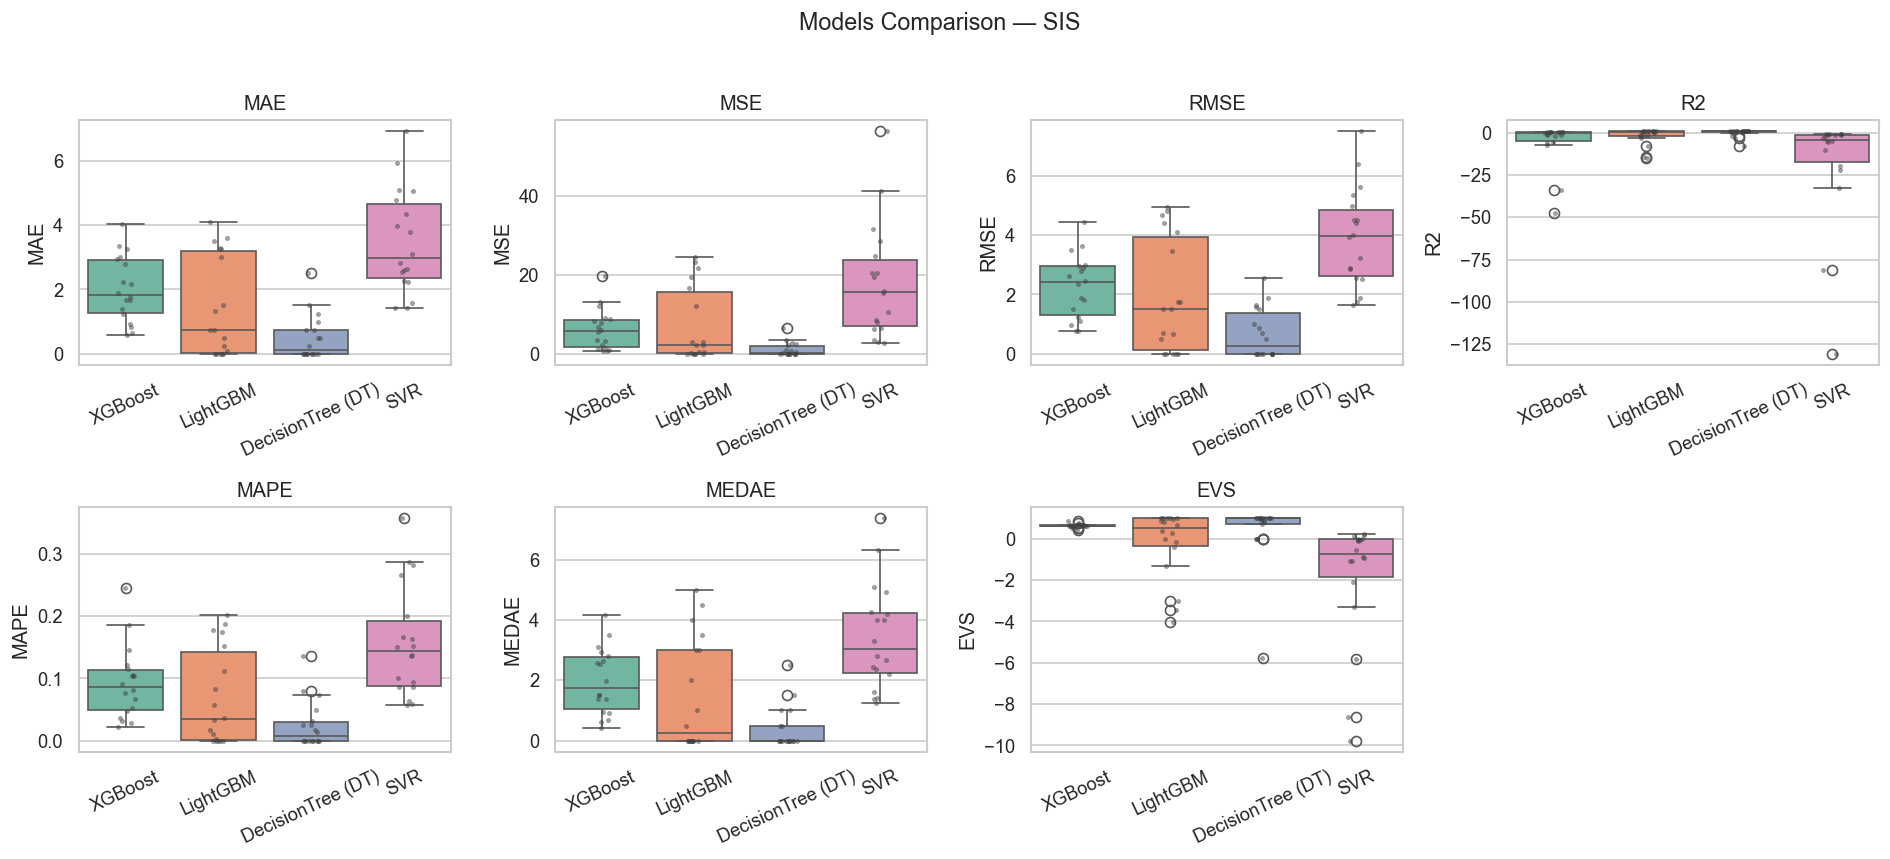

Salvato: C:\Users\Alessio\OneDrive - Università Politecnica delle Marche (1)\Git_Projects\2) Machine Learning Group\MAISON-ML\Development AG\new_results\figures_regression\boxplot_models_oks.png


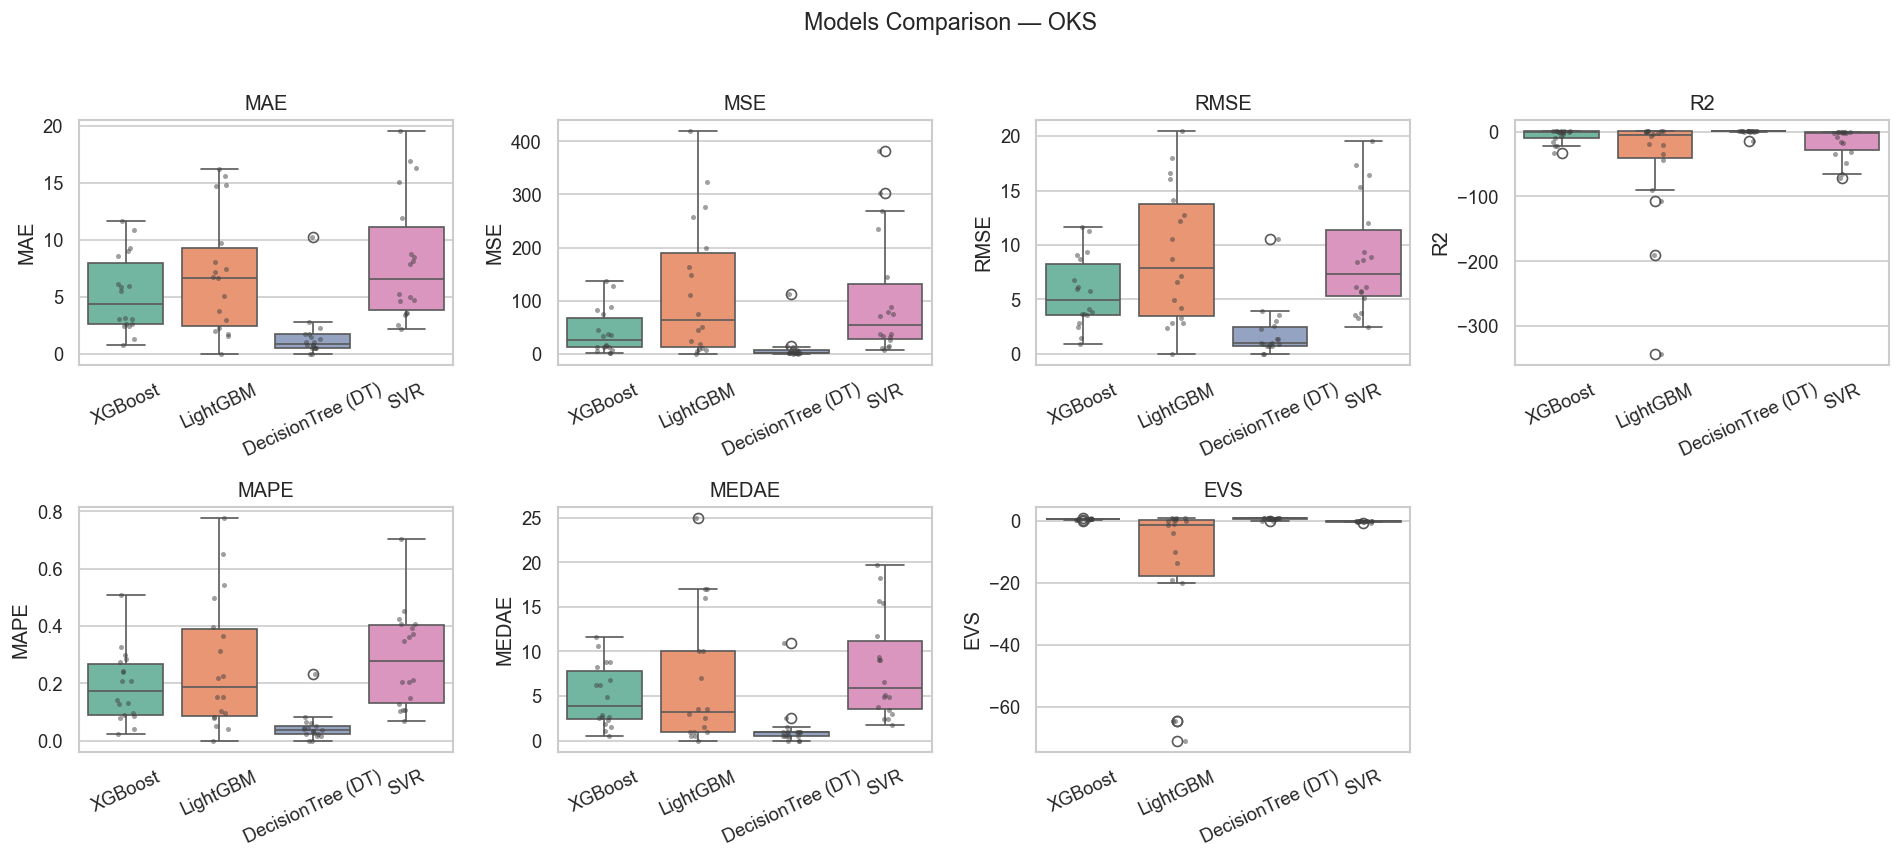

In [7]:
def plot_model_boxplots(df: pd.DataFrame, sheet_name: str, save: bool = True) -> None:
    plot_df = df.copy()
    plot_df["Model"] = pd.Categorical(plot_df["Model"], categories=MODEL_ORDER, ordered=True)
    plot_df = plot_df.sort_values("Model")

    n_metrics = len(METRICS)
    n_cols = 4
    n_rows = (n_metrics + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    axes = axes.flatten()

    for ax, metric in zip(axes, METRICS):
        sns.boxplot(
            data=plot_df,
            x="Model",
            y=metric,
            order=MODEL_ORDER,
            hue="Model",
            palette="Set2",
            legend=False,
            ax=ax,
        )
        sns.stripplot(
            data=plot_df,
            x="Model",
            y=metric,
            order=MODEL_ORDER,
            color="0.25",
            size=3,
            alpha=0.5,
            ax=ax,
        )
        ax.set_title(metric)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=25)

    for ax in axes[n_metrics:]:
        ax.set_visible(False)

    fig.suptitle(f"Models Comparison — {sheet_name.upper()}", fontsize=14, y=1.02)
    fig.tight_layout()

    if save:
        out_path = FIGURES_DIR / f"boxplot_models_{sheet_name}.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"Salvato: {out_path}")

    plt.show()


for sheet_name, df in sheets.items():
    plot_model_boxplots(df, sheet_name)

## Esportazione tabelle riassuntive (opzionale)

In [6]:
summary_path = BASE_DIR / "new_results" / "summary_regression_stats.xlsx"
with pd.ExcelWriter(summary_path) as writer:
    for sheet_name, table in summary_tables.items():
        table.to_excel(writer, sheet_name=sheet_name)
print(f"Tabelle salvate in: {summary_path}")

Tabelle salvate in: C:\Users\Alessio\OneDrive - Università Politecnica delle Marche (1)\Git_Projects\2) Machine Learning Group\MAISON-ML\Development AG\new_results\summary_regression_stats.xlsx
